##  Task 4(b): Take a grayscale image of size 512x512, add some Gaussian Noise & observe the Ringing Effect of Ideal Low Pass Filter on the image. Use different radius of Ideal Low Pass Filter & display their results

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Function for Ideal Low Pass Filter

In [2]:
def apply_ideal_low_pass_filter(image, cutoff_freq):
    height, width = image.shape
    ideal_filter = np.zeros((height, width))

    for u in range(height):
        for v in range(width):
            D = np.sqrt((u - height/2)**2 + (v - width/2)**2)
            if(D<cutoff_freq):
                ideal_filter[u,v] = 1
    filtered_image = image * ideal_filter
    filtered_image = np.fft.ifftshift(filtered_image)
    filtered_image = np.fft.ifft2(filtered_image)

    return np.abs(filtered_image)

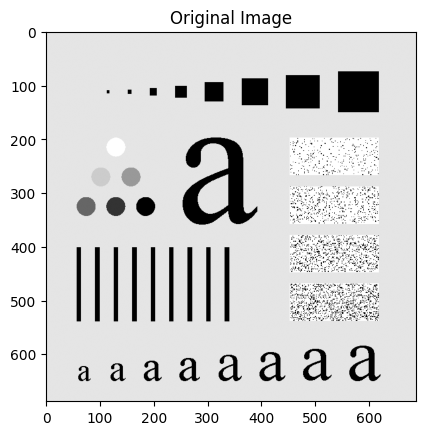

In [3]:
character_image_pattern = cv2.imread("./Characters Test Pattern 688x688 (1).tif", 0)
plt.imshow(character_image_pattern, cmap='gray')
plt.title("Original Image")
plt.show()

## Adding Gaussian Noise

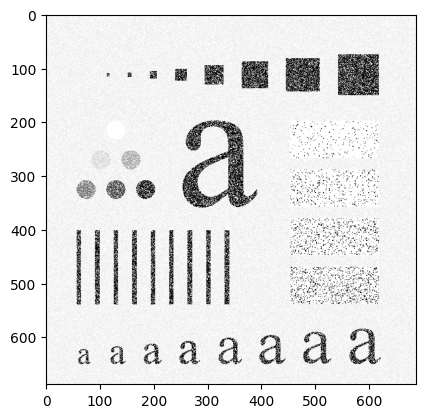

In [5]:
gaussian_noise = np.random.normal(7, 13, character_image_pattern.shape).astype(np.uint8)
noisy_character_image = cv2.add(character_image_pattern, gaussian_noise)
plt.imshow(noisy_character_image, cmap='gray')
plt.show()

## Applying FFT (Fast Fourier Transform)

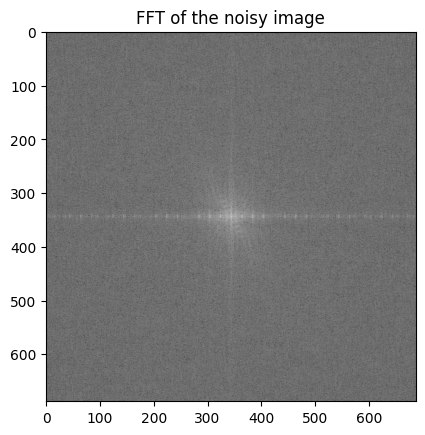

In [8]:
noisy_image_fft = np.fft.fftshift(np.fft.fft2(noisy_character_image))
plt.imshow(np.log(np.abs(noisy_image_fft)), cmap='gray')
plt.title("FFT of the noisy image")
plt.show()


## Applying Ideal Low Pass Filters of various Radius or Cutoff Frequency

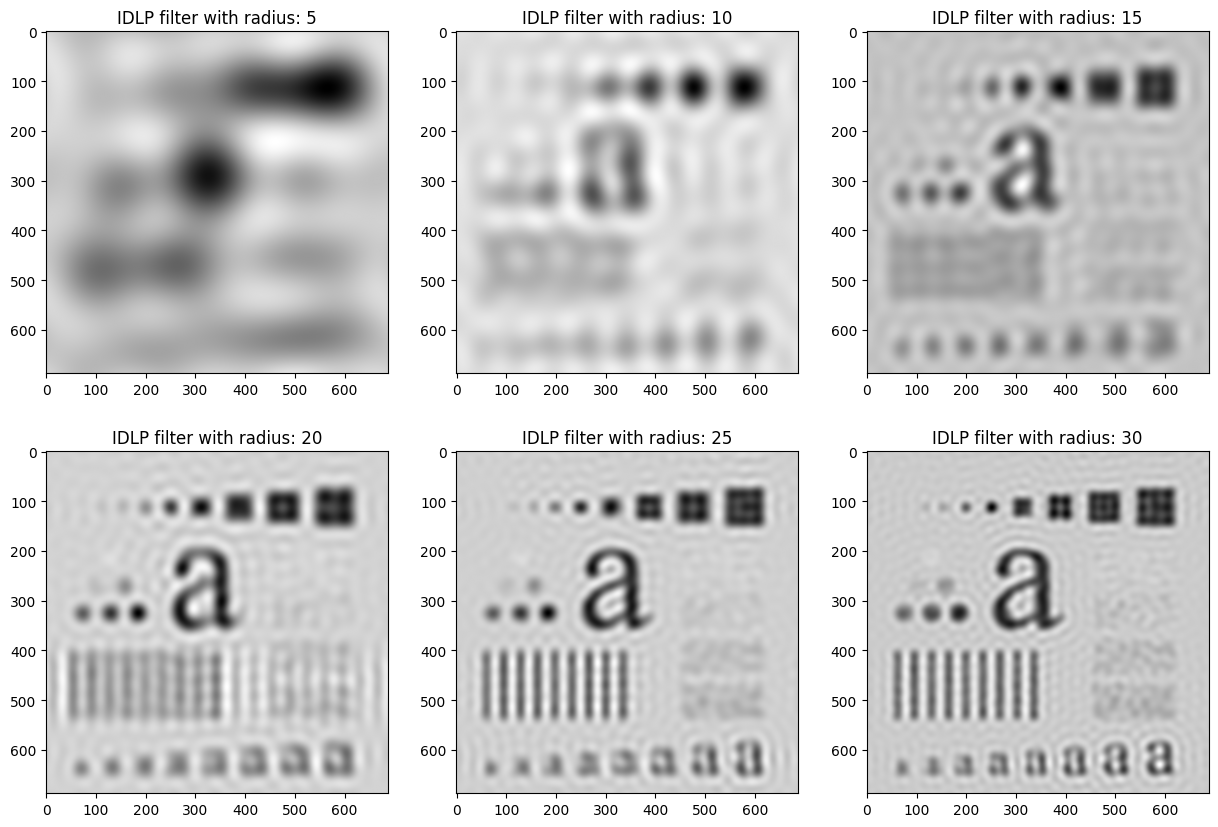

In [9]:
plt.figure(figsize=(15, 10))

for r in range(1, 7):
    filtered_image = apply_ideal_low_pass_filter(noisy_image_fft, r*5)
    plt.subplot(2,3,r)
    plt.imshow(filtered_image, cmap='gray')
    plt.title(f"IDLP filter with radius: {r*5}")
plt.show()